In [101]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/final_dataset.csv", low_memory=False)

In [102]:
ratings_raw = pd.read_csv("data/ml-latest-small/ratings_cleaned.csv")
df = df.merge(ratings_raw[["userId", "movieId", "timestamp"]], on=["userId", "movieId"], how="left")
df["rating_year"] = pd.to_datetime(df["timestamp"], unit="s").dt.year
df["rating_decade"] = (df["rating_year"] // 10 * 10).astype("Int64")

<Axes: title={'center': 'Liczba ocen w czasie'}, xlabel='rating_year'>

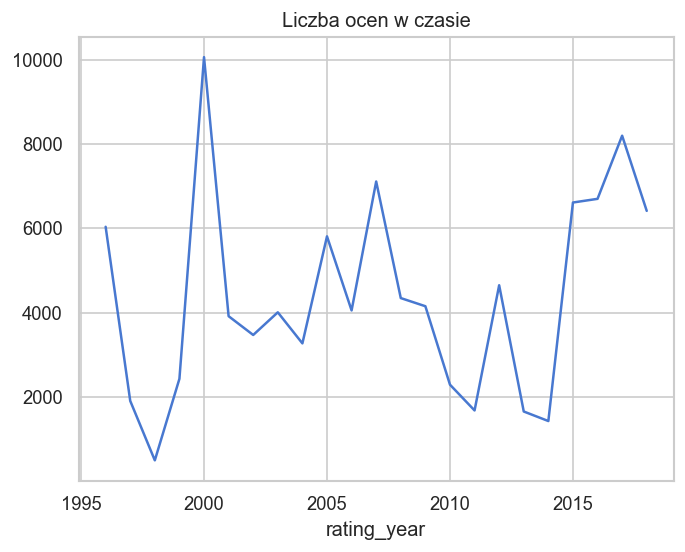

In [103]:
ratings_per_year = df.groupby("rating_year").size()
ratings_per_year.plot(title="Liczba ocen w czasie")

<Axes: title={'center': 'Średnia ocena w czasie'}, xlabel='rating_year'>

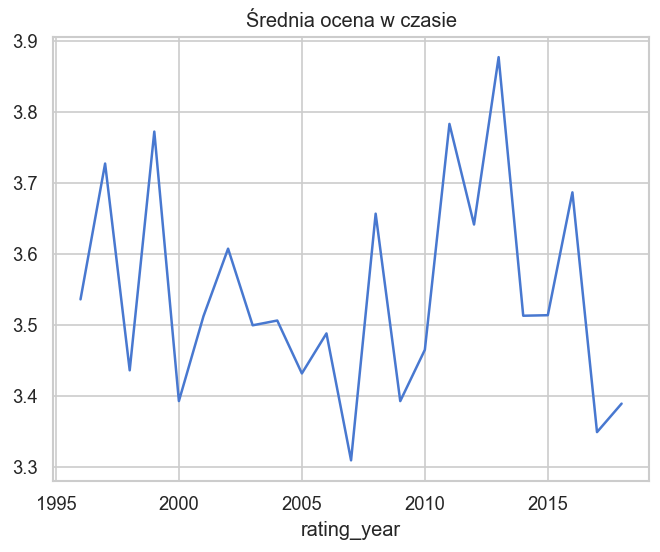

In [104]:
avg_rating_per_year = df.groupby("rating_year")["rating"].mean()
avg_rating_per_year.plot(title="Średnia ocena w czasie")

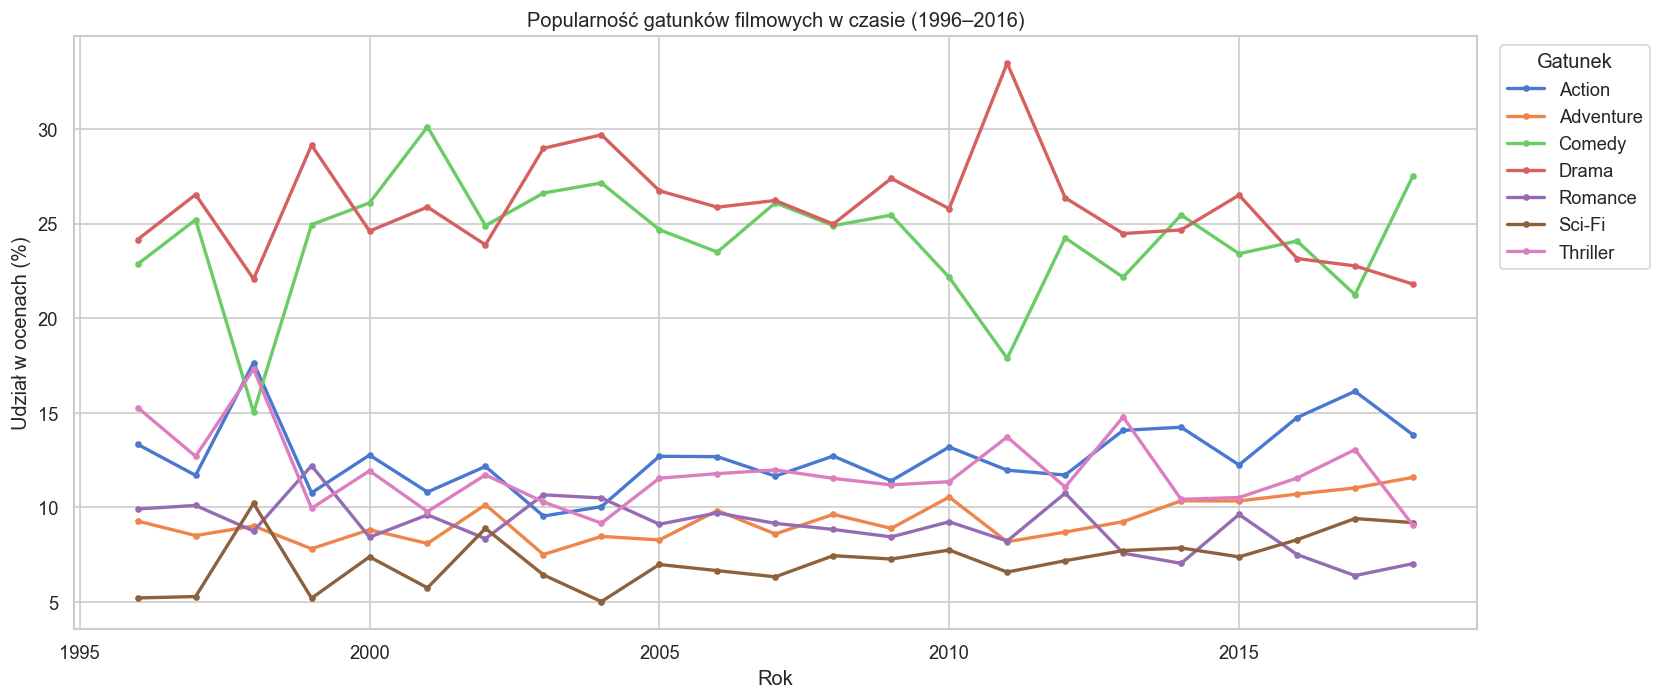

In [105]:
genre_ratings = df.copy()
genre_ratings["rating_year"] = pd.to_datetime(genre_ratings["timestamp"], unit="s").dt.year
genre_ratings["genre"] = genre_ratings["genres_x"].str.split("|")
genre_ratings = genre_ratings.explode("genre")
genre_ratings = genre_ratings[~genre_ratings["genre"].isin(["(no genres listed)", "IMAX"])]
top_genres = genre_ratings["genre"].value_counts().head(7).index
genre_ratings = genre_ratings[genre_ratings["genre"].isin(top_genres)]
genre_ratings["n_genres"] = genre_ratings["genres_x"].str.split("|").apply(len)
genre_ratings["weight"] = 1 / genre_ratings["n_genres"]

plot1 = (genre_ratings.groupby(["rating_year", "genre"])["weight"].sum().unstack(fill_value=0))
plot1 = plot1.div(plot1.sum(axis=1), axis=0) * 100
plot1.plot(kind="line", figsize=(14, 6), marker="o", markersize=3, linewidth=2)
plt.title("Popularność gatunków filmowych w czasie (1996–2016)")
plt.xlabel("Rok")
plt.ylabel("Udział w ocenach (%)")
plt.legend(title="Gatunek", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()